# Oberry loyalty data — exploratory analysis

Working notebook against `data/raw/`. Every figure is saved to `outputs/figures/` at 150 dpi for reuse in the deck.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_END = pd.Timestamp("2026-06-30") + pd.Timedelta(days=1)  # inclusive of 2026-06-30
CHURN_SILENCE_DAYS = 60

# Project palette — used consistently across every figure in this project.
NAVY, TEAL, GOLD, CORAL, SLATE = "#1F3B57", "#2E8B7A", "#D4A03C", "#D65C4A", "#5B7C99"
PALETTE = [NAVY, TEAL, GOLD, CORAL, SLATE]

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

members = pd.read_csv(RAW / "members.csv", parse_dates=["signup_date"])
txns = pd.read_csv(RAW / "transactions.csv", parse_dates=["transaction_date"])

print(f"members: {len(members):,}   transactions: {len(txns):,}")
members.head()

members: 20,000   transactions: 278,644


,member_id,signup_date,tier,home_branch,age_band,city
0,M000001,2024-10-07,Silver,B27,45-54,Chiang Mai
1,M000002,2026-01-26,Bronze,B19,35-44,Bangkok
2,M000003,2025-08-29,Bronze,B39,45-54,Khon Kaen
3,M000004,2026-05-29,Silver,B07,25-34,Bangkok
4,M000005,2025-08-27,Silver,B24,35-44,Bangkok


## Per-member profile

A small set of candidate RFM-style features, built once and reused across the charts below (and again in the correlation heatmap at the end).

In [2]:
last_txn = txns.groupby("member_id")["transaction_date"].max().rename("last_transaction")
frequency = txns.groupby("member_id").size().rename("frequency")
monetary = txns.groupby("member_id")["amount_thb"].sum().rename("monetary")
redemption_count = (
    txns.groupby("member_id")["points_redeemed"].apply(lambda s: (s > 0).sum()).rename("redemption_count")
)
distinct_branches = txns.groupby("member_id")["branch_id"].nunique().rename("distinct_branches")

profile = (
    members.set_index("member_id")
    .join(last_txn)
    .join(frequency)
    .join(monetary)
    .join(redemption_count)
    .join(distinct_branches)
)

profile["recency_days"] = (WINDOW_END - profile["last_transaction"]).dt.days
profile["tenure_days"] = (WINDOW_END - profile["signup_date"]).dt.days
profile["churned"] = profile["recency_days"] > CHURN_SILENCE_DAYS
profile["ever_redeemed"] = profile["redemption_count"] > 0

# Home-branch share: fraction of a member's own visits at their registered home branch.
home_hits = txns.merge(members[["member_id", "home_branch"]], on="member_id")
profile["home_branch_share"] = (
    (home_hits["branch_id"] == home_hits["home_branch"]).groupby(home_hits["member_id"]).mean()
)


def _gap_stats(dates: pd.Series) -> pd.Series:
    d = dates.sort_values()
    if len(d) < 2:
        return pd.Series({"mean_gap_days": np.nan, "gap_trend": np.nan})
    gaps = d.diff().dt.total_seconds().div(86400).dropna()
    recent, historical = gaps.tail(3), gaps.iloc[: max(0, len(gaps) - 3)]
    trend = recent.mean() / historical.mean() if len(historical) else np.nan
    return pd.Series({"mean_gap_days": gaps.mean(), "gap_trend": trend})


gap_df = txns.groupby("member_id")["transaction_date"].apply(_gap_stats).unstack()
profile = profile.join(gap_df)

print(f"profile: {len(profile):,} members, {profile['churned'].mean():.1%} churned")
profile.head()

profile: 20,000 members, 26.4% churned


,signup_date,tier,home_branch,age_band,city,last_transaction,frequency,monetary,redemption_count,distinct_branches,recency_days,tenure_days,churned,ever_redeemed,home_branch_share,mean_gap_days,gap_trend
member_id,,,,,,,,,,,,,,,,,
M000001,2024-10-07,Silver,B27,45-54,Chiang Mai,2025-06-04 08:15:00,14,2839.48,0,3,391,632,True,False,0.857143,18.422596,1.629903
M000002,2026-01-26,Bronze,B19,35-44,Bangkok,2026-06-12 16:17:00,7,1837.08,0,1,18,156,False,False,1.000000,22.887500,1.454058
M000003,2025-08-29,Bronze,B39,45-54,Khon Kaen,2026-06-18 08:08:00,12,1586.14,0,4,12,306,False,False,0.750000,26.625568,0.993003
M000004,2026-05-29,Silver,B07,25-34,Bangkok,2026-06-15 07:03:00,2,748.89,0,1,15,33,False,False,1.000000,16.402083,NaN
M000005,2025-08-27,Silver,B24,35-44,Bangkok,2026-03-24 20:36:00,11,2170.15,0,2,98,308,True,False,0.909091,20.959792,1.538400


## 1. Churn rate by days-since-last-activity

Members bucketed by `recency_days` (days since their last transaction), with the 60-day churn threshold marked. Bars past the line are members who meet the churn definition today.

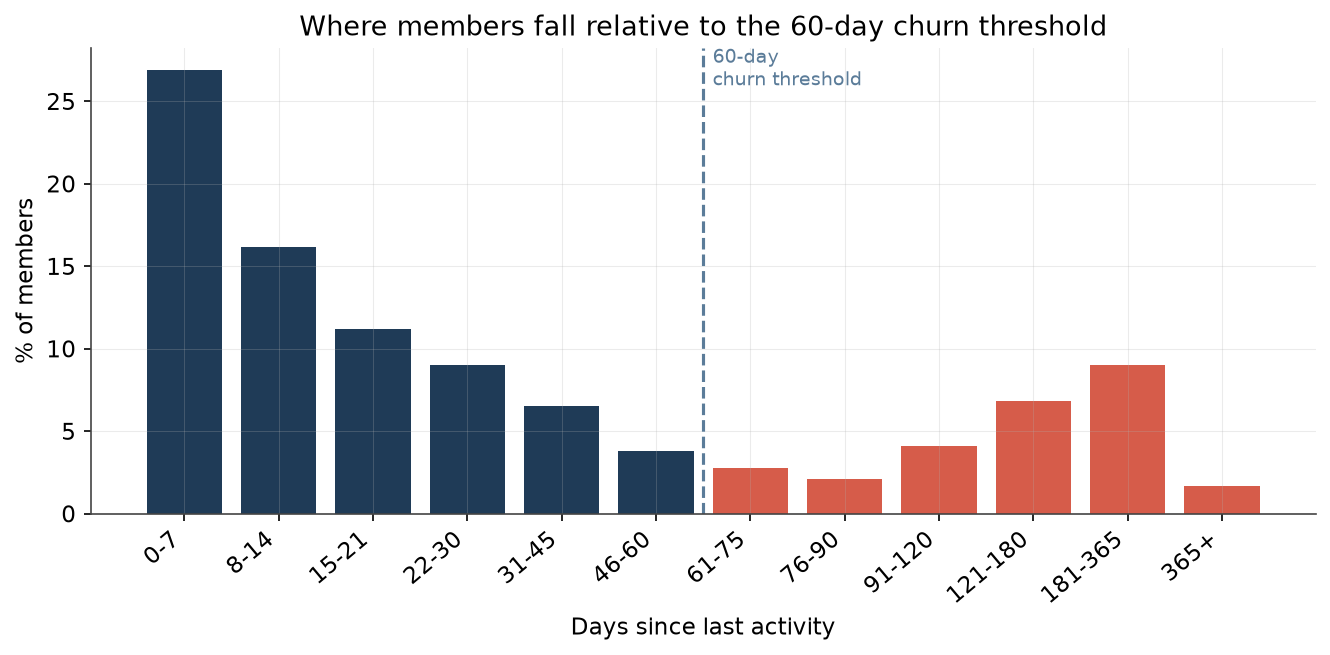

In [3]:
bins = [0, 7, 14, 21, 30, 45, 60, 75, 90, 120, 180, 365, 10_000]
labels = ["0-7", "8-14", "15-21", "22-30", "31-45", "46-60", "61-75", "76-90", "91-120", "121-180", "181-365", "365+"]
profile["recency_bucket"] = pd.cut(profile["recency_days"], bins=bins, labels=labels, include_lowest=True)

bucket_counts = profile.groupby("recency_bucket", observed=True).size().reindex(labels)
bucket_pct = bucket_counts / bucket_counts.sum() * 100
colors = [CORAL if int(lbl.split("-")[0].rstrip("+")) > 60 else NAVY for lbl in labels]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, bucket_pct.values, color=colors)
ax.axvline(x=5.5, color=SLATE, linestyle="--", linewidth=1.5)
ax.text(5.6, ax.get_ylim()[1] * 0.92, "60-day\nchurn threshold", color=SLATE, fontsize=9)
ax.set_ylabel("% of members")
ax.set_xlabel("Days since last activity")
ax.set_title("Where members fall relative to the 60-day churn threshold")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_recency_distribution.png", dpi=150)
plt.show()

*Observation:* the distribution drops off sharply after the first few weeks, and while there's a secondary bump among members who've been silent for 4-12 months, there's no pile-up of members sitting right at the 60-day line itself — the threshold cuts through a genuinely thin part of the distribution, not a contested one.

## 2. Basket size and inter-visit gap distributions

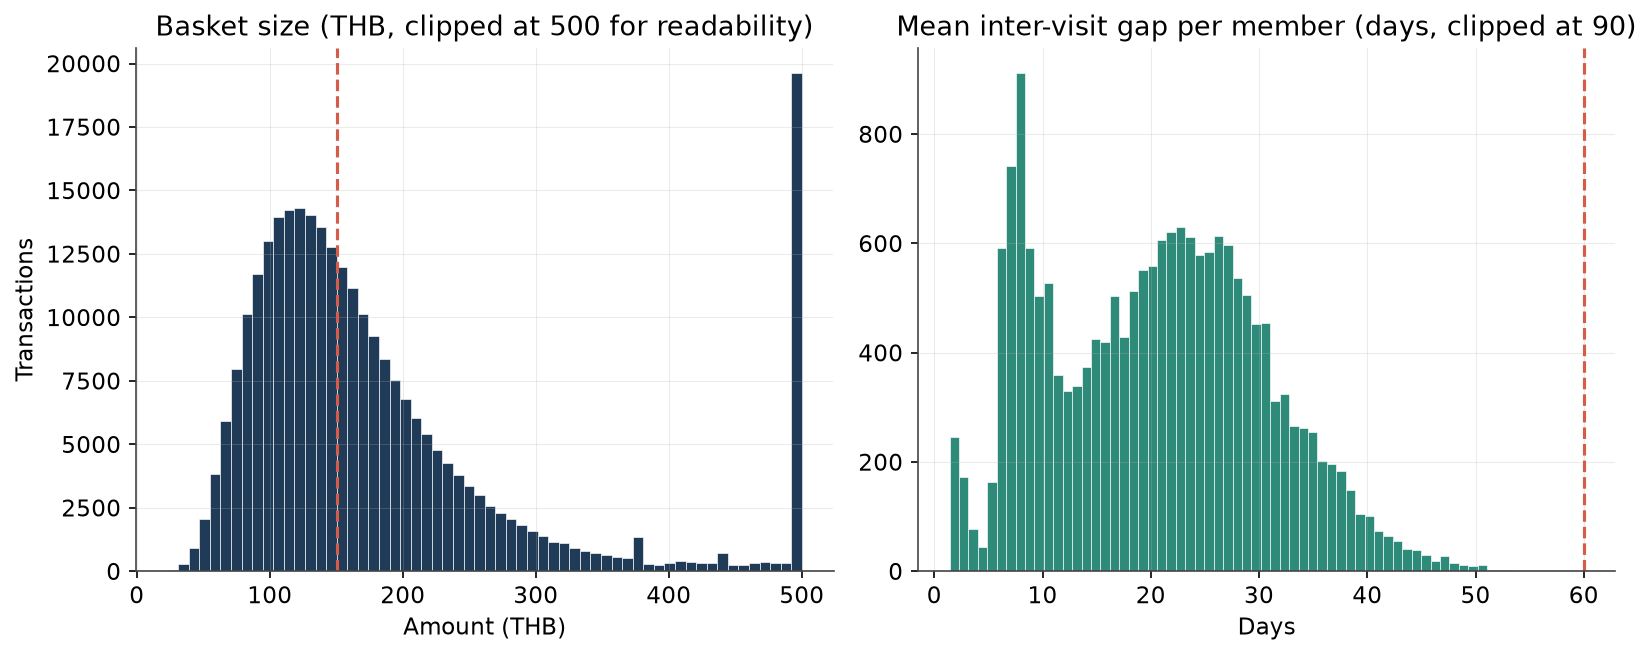

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(txns["amount_thb"].clip(upper=500), bins=60, color=NAVY, edgecolor="white", linewidth=0.3)
axes[0].axvline(txns["amount_thb"].median(), color=CORAL, linestyle="--", linewidth=1.5)
axes[0].set_title("Basket size (THB, clipped at 500 for readability)")
axes[0].set_xlabel("Amount (THB)")
axes[0].set_ylabel("Transactions")

gap_vals = profile["mean_gap_days"].dropna().clip(upper=90)
axes[1].hist(gap_vals, bins=60, color=TEAL, edgecolor="white", linewidth=0.3)
axes[1].axvline(CHURN_SILENCE_DAYS, color=CORAL, linestyle="--", linewidth=1.5)
axes[1].set_title("Mean inter-visit gap per member (days, clipped at 90)")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_basket_and_gap_distributions.png", dpi=150)
plt.show()

*Observation:* basket size is right-skewed around the ~145 THB median with a long tail from group orders, and most members' average gap sits well under the 60-day line — the members drifting past it are the exception, not the norm.

## 3. Churn rate by tier, and by redemption status

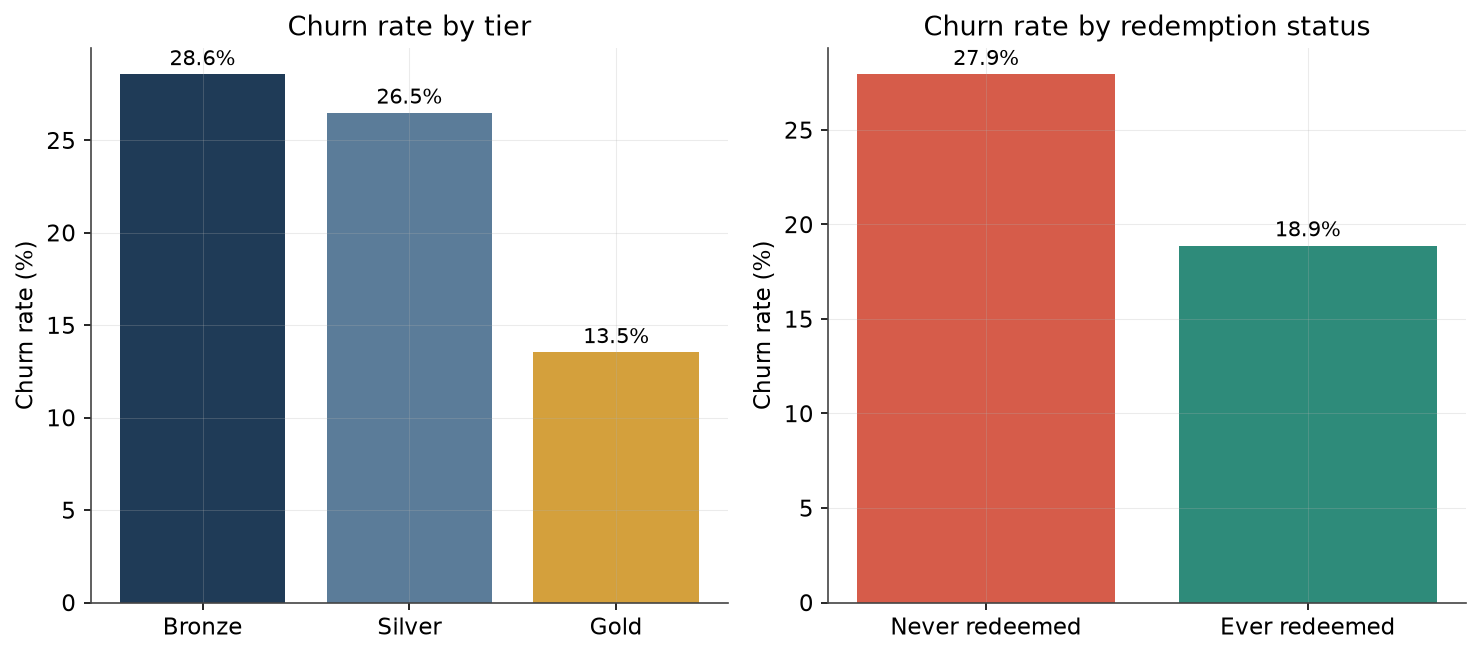

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

tier_order = ["Bronze", "Silver", "Gold"]
tier_churn = profile.groupby("tier")["churned"].mean().reindex(tier_order) * 100
axes[0].bar(tier_order, tier_churn.values, color=[NAVY, SLATE, GOLD])
axes[0].set_ylabel("Churn rate (%)")
axes[0].set_title("Churn rate by tier")
for i, v in enumerate(tier_churn.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

redeem_labels = ["Never redeemed", "Ever redeemed"]
redeem_churn = profile.groupby("ever_redeemed")["churned"].mean().reindex([False, True]) * 100
axes[1].bar(redeem_labels, redeem_churn.values, color=[CORAL, TEAL])
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_title("Churn rate by redemption status")
for i, v in enumerate(redeem_churn.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_churn_by_tier_and_redemption.png", dpi=150)
plt.show()

*Observation:* Gold churns noticeably less than Bronze/Silver, and members who have never redeemed a point churn substantially more than those who have — both patterns match what Part D's generator was designed to bake in, which is a useful sanity check on the data itself.

## 4. Monthly active members over time

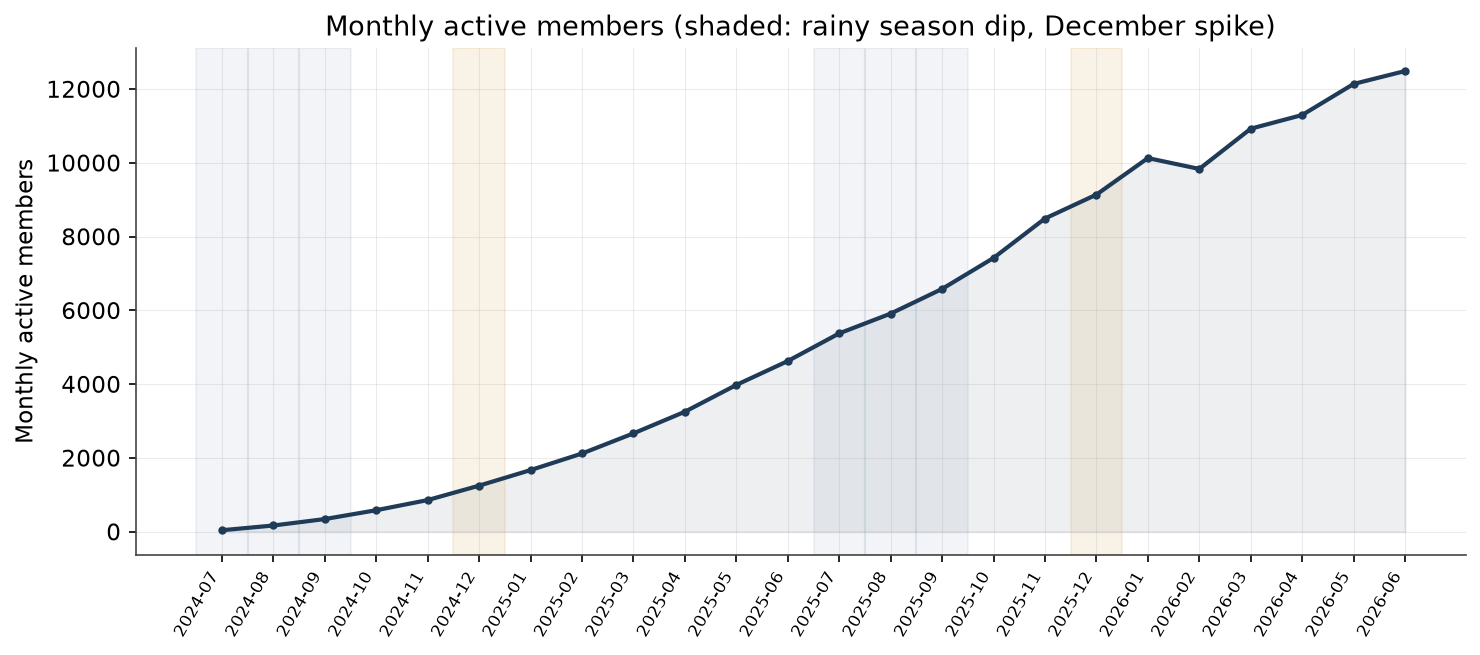

In [6]:
txns["month"] = txns["transaction_date"].dt.to_period("M")
monthly_active = txns.groupby("month")["member_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_active.index.astype(str), monthly_active.values, color=NAVY, linewidth=2, marker="o", markersize=3)
ax.fill_between(range(len(monthly_active)), monthly_active.values, color=NAVY, alpha=0.08)

# Rainy season (Jul-Sep) and December shading, matching the generator's seasonality.
for i, period in enumerate(monthly_active.index):
    if period.month in (7, 8, 9):
        ax.axvspan(i - 0.5, i + 0.5, color=SLATE, alpha=0.08)
    elif period.month == 12:
        ax.axvspan(i - 0.5, i + 0.5, color=GOLD, alpha=0.12)

ax.set_ylabel("Monthly active members")
ax.set_title("Monthly active members (shaded: rainy season dip, December spike)")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_monthly_active_members.png", dpi=150)
plt.show()

*Observation:* growth (signups skew toward the recent end of the window) dominates this view — the rainy-season dip and December bump the generator bakes in are real in the underlying data but subtle against that trend at the aggregate monthly level, not something you'd spot from this chart alone.

## 5. Correlation heatmap of candidate numeric features

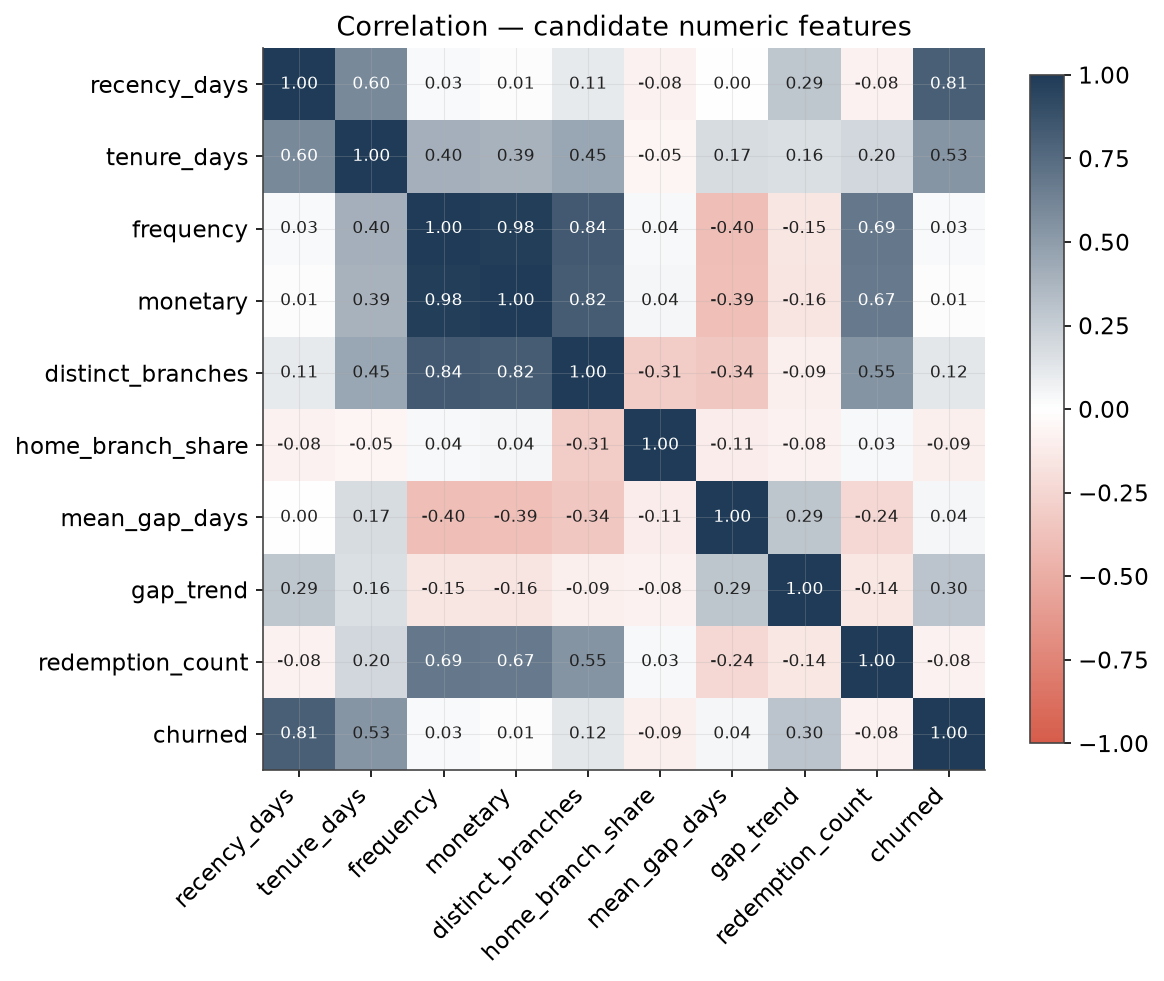

In [7]:
from matplotlib.colors import LinearSegmentedColormap

candidate_cols = [
    "recency_days", "tenure_days", "frequency", "monetary",
    "distinct_branches", "home_branch_share", "mean_gap_days",
    "gap_trend", "redemption_count", "churned",
]
corr = profile[candidate_cols].astype(float).corr()

diverging = LinearSegmentedColormap.from_list("project_diverging", [CORAL, "#FFFFFF", NAVY])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(candidate_cols)))
ax.set_xticklabels(candidate_cols, rotation=45, ha="right")
ax.set_yticks(range(len(candidate_cols)))
ax.set_yticklabels(candidate_cols)
for i in range(len(candidate_cols)):
    for j in range(len(candidate_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(corr.values[i, j]) > 0.55 else "#222222")
ax.set_title("Correlation — candidate numeric features")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_correlation_heatmap.png", dpi=150)
plt.show()

*Observation:* `recency_days` correlates most strongly with `churned` (unsurprising — it's what defines the label), `tenure_days` and `gap_trend` follow at a real distance behind it, and `mean_gap_days` is barely correlated at all (0.04) — evidence that it's specifically the *widening trend* relative to a member's own baseline that carries signal, not their raw average cadence.